In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *

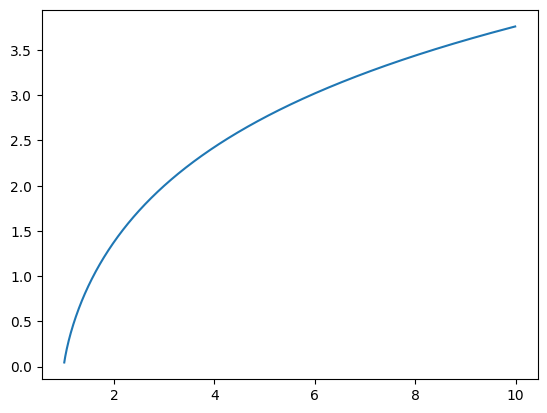

In [2]:
G = lambda X: np.array([g(x) for x in X])

X= np.arange(1.01, 10.0, 0.01)
plt.plot(X, G(X))

# Continuous-variable QKD key rates

In this notebook we are computing the secret key rates for CV-QKD protocols following the calculations in Table III (below) of Zhang et al.'s "_Continuous-variable quantum key distribution system: Past, present, and future_" (2024), __[APR version](https://pubs.aip.org/aip/apr/article/11/1/011318/3279669/Continuous-variable-quantum-key-distribution)__. 

The __[arXiv](https://arxiv.org/pdf/2310.04831)__ version does not have the table but it has an in-text explanation.

NOTE: the $G(x)$ in the table corresponds to the `g(x)` entropy function defined in `qopt_funcs`.

![alt text](zhang_table.png)

In [3]:
V = 5
T_resolution = 0.01
T= np.arange(T_resolution, .99, T_resolution) # extreme values of T cause numerical issues
exc_noise = 0.1
chi = (1 - T)/T + exc_noise
a, b, c = V, T*(V + chi), np.sqrt(T*(V**2 - 1))
Delta = a**2 + b**2 - 2*c**2
D = a*b - c**2
A = (a + b*D + Delta)/(a + 1)
A_prime = (b + a*D + Delta)/(b + 1)
B = D*(b + D)/(a + 1)
B_prime = D*(a + D)/(b + 1)

## Functions for computing the key rate

- Mutual information is the (classical) expression for a bivariate Gaussian distribution, given the covariance matrix.

- Holevo bound depends on the symplectic eigenvalues of the covariance matrix, before and after (= conditioned to) the measurement. 

The expressions of the eigenvalues of the cov. mtx and of the conditional cov. mtx, are taken from Table III (To avoid confusion, the ```lambdas``` are numbered according to Zhang's notation)

All possible combinations of homo-/hetero-dyne measurement, squeezed/coherent states, direct/reverse reconciliation are considered. 

In [4]:
# i know it's a mess, i'm calling global variables inside the functions, as long as it works for now. i'll oop it eventually

def mutual_information_CV(T, states='squeezed', detection_mode='homodyne'):   # I_AB does NOT depend on the reconc scheme
    if states == 'squeezed' and detection_mode == 'homodyne':
        return 0.5*np.log2(V + chi)/(chi + 1/V)
    elif states == 'coherent' and detection_mode == 'homodyne':
        return 0.5*np.log2((V + chi)/(chi + 1))
    
    elif states == 'squeezed' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1/V) + 1)
    elif states == 'coherent' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1) + 1)
    
    else:
        raise ValueError("Invalid \'states\' or \'detection_mode\' argument")


def holevo_bound_CV(T, states='squeezed', detection_mode='homodyne', reconciliation='direct'):

    lambdas = np.zeros((13, len(T)))    # leaving the 1st one empty to use indeces from 1 to 12
    lambdas[0] = T    # to keep track of the transmittance values

    # Alice and Bob's covariance matrix eigenvalues before measurement
    lambdas[1] = np.sqrt(0.5*(Delta + np.sqrt(Delta**2 - 4*D**2)))
    lambdas[2] = np.sqrt(0.5*(Delta - np.sqrt(Delta**2 - 4*D**2)))


    # HOMODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[3] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[4] = np.sqrt(V*(V*chi + 1)/(chi + V))

    ## coherent states
    ### direct reconciliation
    lambdas[5] = np.sqrt(0.5*(A + np.sqrt(A**2 - 4*B)))
    lambdas[6] = np.sqrt(0.5*(A - np.sqrt(A**2 - 4*B)))
    ### reverse reconciliation
    lambdas[7] = np.sqrt(V*(V*chi + 1)/(chi + V))


    # HETERODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[8] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[9] = np.sqrt(0.5*(A_prime + np.sqrt(A_prime**2 - 4*B_prime)))
    lambdas[10] = np.sqrt(0.5*(A_prime - np.sqrt(A_prime**2 - 4*B_prime)))

    ## coherent states
    ### direct reconciliation
    lambdas[11] = T*(chi + 1)
    ### reverse reconciliation
    lambdas[12] = (T*(V*chi + 1) + 1)/(T*(V + chi) + 1)

    with np.printoptions(threshold=np.inf):
        print(lambdas)
        
    if states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[3]) 
    elif states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[4])
    
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[5]) - g(lambdas[6])
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[7])
    
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[8]) 
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[9]) - g(lambdas[10])
    
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[11])
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[12])
    
    else:
        raise ValueError("Invalid \'states\', \'detection_mode\' or \'reconciliation\' argument")



coherent homodyne direct
[[0.01       0.02       0.03       0.04       0.05       0.06
  0.07       0.08       0.09       0.1        0.11       0.12
  0.13       0.14       0.15       0.16       0.17       0.18
  0.19       0.2        0.21       0.22       0.23       0.24
  0.25       0.26       0.27       0.28       0.29       0.3
  0.31       0.32       0.33       0.34       0.35       0.36
  0.37       0.38       0.39       0.4        0.41       0.42
  0.43       0.44       0.45       0.46       0.47       0.48
  0.49       0.5        0.51       0.52       0.53       0.54
  0.55       0.56       0.57       0.58       0.59       0.6
  0.61       0.62       0.63       0.64       0.65       0.66
  0.67       0.68       0.69       0.7        0.71       0.72
  0.73       0.74       0.75       0.76       0.77       0.78
  0.79       0.8        0.81       0.82       0.83       0.84
  0.85       0.86       0.87       0.88       0.89       0.9
  0.91       0.92       0.93       0.94       0.

c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:37: RuntimeWarning: divide by zero encountered in log2
  return (x+1)/2 * np.log2((x+1)/2) - (x-1)/2 * np.log2((x-1)/2)
c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:37: RuntimeWarning: invalid value encountered in multiply
  return (x+1)/2 * np.log2((x+1)/2) - (x-1)/2 * np.log2((x-1)/2)


ValueError: Unphysical (less than 1) symplectic eigenvalues detected: min = 0.4270521768029246

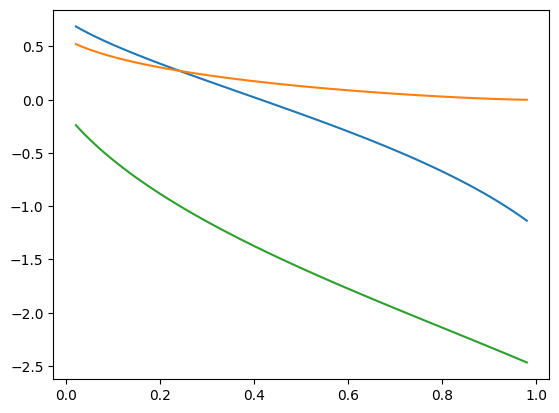

In [5]:
state_class = ['coherent']
det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']

from itertools import product

for states, det_mode, rec_mode in product(state_class, det_modes, reconciliation_modes):
    print(states, det_mode, rec_mode)
    plt.plot(1-T, mutual_information_CV(T, states, det_mode) - holevo_bound_CV(T, states, det_mode, rec_mode), label=f'{states}, {det_mode}, {rec_mode}')
plt.xlabel('Loss $(1 - T)$')
plt.legend()
plt.grid()


# NOT WORKING YET --> SYMP EIGVALS LESS THAN 1

# trying to generalize to coherent state protocols

c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  return (x+1)/2 * np.log2((x+1)/2) - (x-1)/2 * np.log2((x-1)/2)


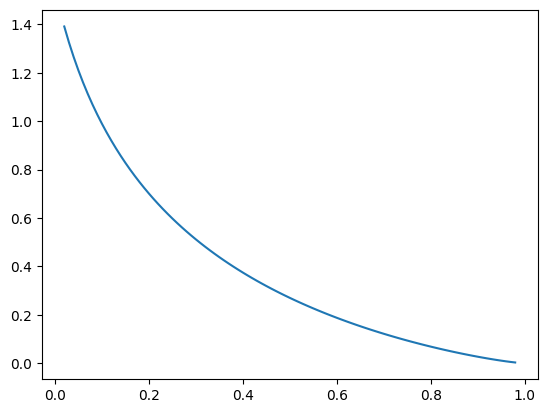

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *

rates = [CV_keyrate(5, t, exc_noise, alice_detection_mode='homodyne', detection_mode='heterodyne', reconciliation='reverse') for t in T]
plt.plot(1-T, rates)

homodyne homodyne direct [-0.06515605510756295, -0.1125523791745886, -0.1537192890780723, -0.19101590772941446, -0.22553395573257973, -0.2579019402270868, -0.2885266330116991, -0.31769166351677836, -0.3456053578341294, -0.37242674441514545, -0.398280889107804, -0.4232685110388892, -0.44747231009334687, -0.47096129574318457, -0.4937938451600403, -0.5160199226828892, -0.537682728085457, -0.5588199451730276, -0.5794647041250376, -0.5996463345874834, -0.6193909630235943, -0.6387219922763263, -0.6576604907590315, -0.6762255114069085, -0.694434355392767, -0.7123027919397953, -0.7298452428962836, -0.7470749387708118, -0.7640040514618693, -0.7806438078070173, -0.7970045872349036, -0.8130960061509163, -0.8289269911829844, -0.8445058430169077, -0.8598402922367585, -0.8749375483365145, -0.8898043428687343, -0.9044469675333935, -0.9188713078791353, -0.9330828731811505, -0.9470868229710978, -0.9608879906211423, -0.9744909043228918, -0.9878998057508401, -1.0011186666567378, -1.014151203603995, -1.02

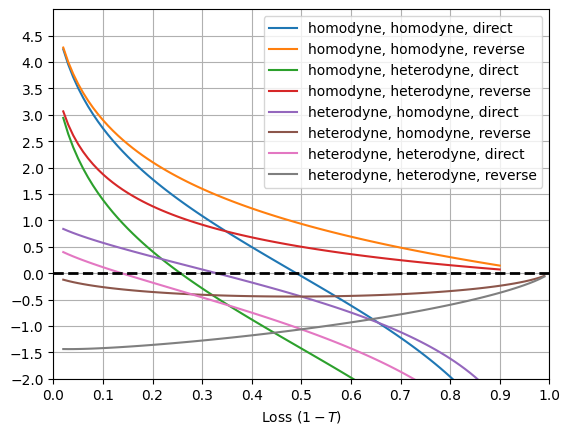

In [22]:
V = 5
T_resolution = 0.01
T= np.arange(T_resolution, .99, T_resolution) # extreme values of T cause numerical issues
exc_noise = 0.01

alice_det_modes = ['homodyne', 'heterodyne']
for a_det, det_mode, rec_mode in product(alice_det_modes, det_modes, reconciliation_modes):
    print(a_det, det_mode, rec_mode, rates)
    rates = [CV_keyrate(5, t, exc_noise, alice_detection_mode=a_det, detection_mode=det_mode, reconciliation=rec_mode) for t in T]
    plt.plot(1-T, rates, label=f'{a_det}, {det_mode}, {rec_mode}')
down, up = -2, 5
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(down, up, 0.5))
plt.ylim(down, up)
plt.xlim(0, 1)
plt.axhline(0, color='black', lw=2, ls='--')
plt.xlabel('Loss $(1 - T)$')
plt.legend()
plt.grid()
